<a href="https://colab.research.google.com/github/Rodrigoldarocha/Analise-de-Vendas-de-E-commercev1/blob/main/An%C3%A1lise_de_Vendas_de_E_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Análise de Vendas de E-commerce

## 🎯 Objetivo
Neste projeto, eu vou analisar dados de vendas de um e-commerce para entender:

- Quais produtos vendem mais
- Qual o faturamento total
- Quais categorias são mais lucrativas

## 🧠 O que estou praticando:
- Manipulação de dados com Pandas
- Análise exploratória (EDA)
- Criação de visualizações
- Geração de insights de negócio

---

In [ ]:
# 📦 Importando as bibliotecas que vou usar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🎨 Ajustando estilo dos gráficos
sns.set(style="whitegrid")

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


## Criando os dados

In [ ]:
# 🎲 Criando um dataset simulado

# 🔒 Uso seed para garantir que os resultados sejam reproduzíveis
np.random.seed(42)

# 📅 Criando datas
datas = pd.date_range(start="2024-01-01", periods=100)

# 🛍️ Definindo produtos e categorias
produtos = ["Notebook", "Smartphone", "Tablet", "Fone", "Monitor"]
categorias = ["Eletrônicos", "Eletrônicos", "Eletrônicos", "Acessórios", "Eletrônicos"]

# 🧱 Montando os dados
data = {
    "data": np.random.choice(datas, 500),
    "produto": np.random.choice(produtos, 500),
    "preco": np.random.uniform(100, 5000, 500),
    "quantidade": np.random.randint(1, 5, 500)
}

# 📊 Criando DataFrame
df = pd.DataFrame(data)

# 🔗 Criando categoria a partir do produto
map_categoria = dict(zip(produtos, categorias))
df["categoria"] = df["produto"].map(map_categoria)

# 💰 Criando faturamento
df["faturamento"] = df["preco"] * df["quantidade"]

# 👀 Visualizando as primeiras linhas
df.head()

,data,produto,preco,quantidade,categoria,faturamento
0,2024-02-21,Fone,671.810714,3,Acessórios,2015.432143
1,2024-04-02,Smartphone,2418.514385,1,Eletrônicos,2418.514385
2,2024-01-15,Tablet,3069.899217,1,Eletrônicos,3069.899217
3,2024-03-12,Monitor,3992.018305,3,Eletrônicos,11976.054915
4,2024-03-01,Notebook,622.826326,3,Eletrônicos,1868.478977


## Explorando os dados

## 🔍 Explorando os dados

Agora vou entender melhor o dataset antes de analisar:

- Ver tipos de dados
- Ver estatísticas
- Identificar possíveis problemas

👉 Essa etapa é essencial em qualquer análise de dados

In [ ]:
# 📌 Verificando estrutura do dataset
df.info()

# 📊 Estatísticas gerais
df.describe()

# 👀 Conferindo algumas linhas
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   data         500 non-null    datetime64[ns]
 1   produto      500 non-null    object        
 2   preco        500 non-null    float64       
 3   quantidade   500 non-null    int64         
 4   categoria    500 non-null    object        
 5   faturamento  500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 23.6+ KB


,data,produto,preco,quantidade,categoria,faturamento
0,2024-02-21,Fone,671.810714,3,Acessórios,2015.432143
1,2024-04-02,Smartphone,2418.514385,1,Eletrônicos,2418.514385
2,2024-01-15,Tablet,3069.899217,1,Eletrônicos,3069.899217
3,2024-03-12,Monitor,3992.018305,3,Eletrônicos,11976.054915
4,2024-03-01,Notebook,622.826326,3,Eletrônicos,1868.478977


In [ ]:
# 🧹 Fazendo uma checagem básica de qualidade dos dados

# 🔄 Garantindo que a coluna de data está no formato correto
df["data"] = pd.to_datetime(df["data"])

# 🚨 Verificando valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

# ✅ Dataset pronto para análise

Valores nulos por coluna:
data           0
produto        0
preco          0
quantidade     0
categoria      0
faturamento    0
dtype: int64


## 📊 Análise de negócio

Agora vou responder algumas perguntas importantes:

- 💰 Qual o faturamento total?
- 📦 Qual produto vende mais?
- 🏷️ Qual categoria gera mais receita?

In [ ]:
# 💰 Calculando faturamento total
faturamento_total = df["faturamento"].sum()
print(f"💰 Faturamento Total: R$ {faturamento_total:,.2f}")

# 📦 Identificando produtos mais vendidos
produto_vendas = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False)

print("\n📦 Produtos mais vendidos:")
print(produto_vendas)

# 🏷️ Faturamento por categoria
faturamento_categoria = df.groupby("categoria")["faturamento"].sum()

print("\n🏷️ Faturamento por categoria:")
print(faturamento_categoria)

💰 Faturamento Total: R$ 3,331,662.67

📦 Produtos mais vendidos:
produto
Monitor       272
Notebook      268
Smartphone    255
Fone          242
Tablet        218
Name: quantidade, dtype: int64

🏷️ Faturamento por categoria:
categoria
Acessórios     6.447591e+05
Eletrônicos    2.686904e+06
Name: faturamento, dtype: float64


## 📈 Visualização dos dados

Agora vou criar gráficos para visualizar melhor os padrões.

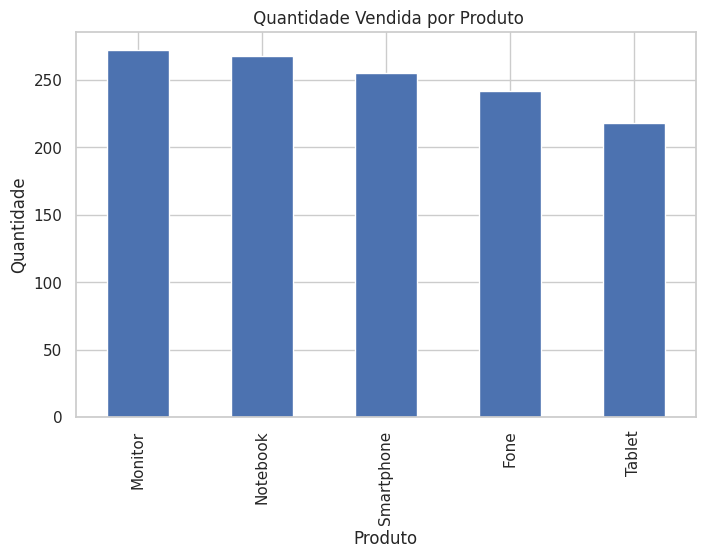

In [ ]:
# 📊 Visualizando quantidade vendida por produto

plt.figure(figsize=(8,5))
produto_vendas.plot(kind='bar')

plt.title(" Quantidade Vendida por Produto")
plt.xlabel("Produto")
plt.ylabel("Quantidade")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


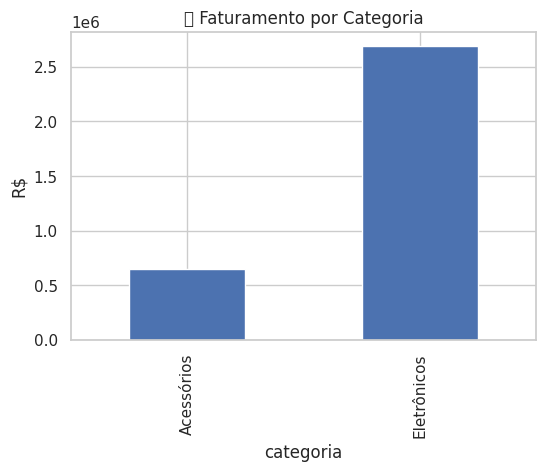

In [ ]:
# 💰 Visualizando faturamento por categoria

plt.figure(figsize=(6,4))
faturamento_categoria.plot(kind='bar')

plt.title("🏷️ Faturamento por Categoria")
plt.ylabel("R$")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


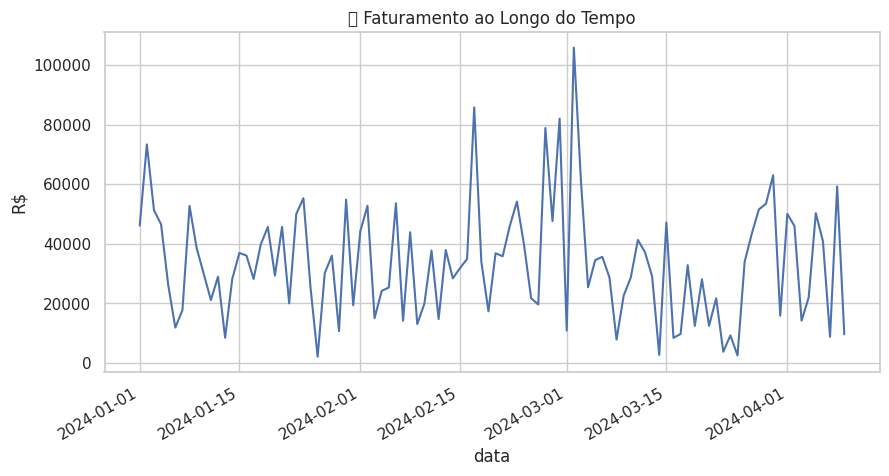

In [ ]:
# 📅 Analisando faturamento ao longo do tempo

df_time = df.groupby("data")["faturamento"].sum()

plt.figure(figsize=(10,5))
df_time.plot()

plt.title("📈 Faturamento ao Longo do Tempo")
plt.ylabel("R$")

plt.show()

## 🧠 Conclusão

Com essa análise, eu consegui:

- Identificar os produtos mais vendidos 📦
- Entender quais categorias geram mais receita 💰
- Visualizar o comportamento das vendas ao longo do tempo 📈
